# Notebook 00 — The Method, Once, On One Name

**This notebook is the walkthrough the desk asked for:** *"a sample of how
the thresholds were tested and the features identified for a certain
ticker, from raw data, cleaning, data analysis — show the full pipeline as
an example."* One instrument — the **semiconductors** theme (anchor ETF:
SMH) — carried from a raw Reddit comment file all the way to a GET IN /
GET OUT flag on a price chart. Simple charts only; every chart says what
to look at.

> **The one question this notebook answers:** how does a pile of Reddit
> posts become a defensible "get out now" flag — and where did every
> number along the way come from?

**What this notebook is NOT:** the evidence. Every number here is a
*window onto* the full research record — notebook 01 (the exam), 02 (the
features), 03 (the tournament), 04 (the evaluation: every threshold swept,
with plots). Where this notebook shows one chart, notebook 04 shows the
sweep it came from, and this notebook reads those results from
`docs/research/nb04_evaluation.json` rather than recomputing them —
stated on each chart.

**The journey, in one table:**

| Stage | What happens | Where the real code lives |
|---|---|---|
| §1 raw → clean | raw comment files are normalised, deduplicated, matched to themes and tickers | `src/clean_data.py`, `src/extract_tickers.py`, `src/themes.py` |
| §2 counts → features | daily counts become the measured ingredients of euphoria | `analytics/euphoria.py`, `analytics/euphoria_phases.py` |
| §3 the feature menu | every candidate feature, and which earned a place | notebook 02, `docs/research/nb02_feature_stats.json` |
| §4 the thresholds | how each trigger level was chosen — sweep, mark, freeze | notebook 04 §1, `docs/research/nb04_evaluation.json` |
| §5 factors → signal | the ingredients averaged, gated, smoothed — and the flag on the price | `analytics/euphoria_phases.py` (production path) |

In [1]:
import io
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.dates as mdates

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

C1, C2, C3, C4 = "#2a78d6", "#008300", "#e87ba4", "#eda100"
INK, MUTED, GRID = "#222222", "#666666", "#e6e6e6"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.dpi": 110, "savefig.bbox": "tight",
})

def despine(ax, keep_bottom=True):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(keep_bottom)

RESEARCH_DIR = ROOT / "docs" / "research"
THEME = "semiconductors"            # the one example this notebook follows
NB_T0 = time.time()

from analytics.plain_english import plain, censor, theme_label  # noqa: E402
print(f"the example: theme '{THEME}' -> shown as "
      f"'{theme_label(THEME)}', anchor ETF SMH")

the example: theme 'semiconductors' -> shown as 'Semiconductors', anchor ETF SMH


---
## §1 RAW → CLEAN: what a post looks like before anything is computed

The archive starts as compressed JSON-lines files of raw Reddit comments
(plus StockTwits and X messages, same shape). Below: a small real sample
from the store, `data/raw/RedditComments/comments_2026-07-24.jsonl.zst`.
Author handles and text are passed through the project's display censor
(`analytics.plain_english.censor`) — the stored data is never rewritten,
only what reaches a screen.

In [2]:
import zstandard as zstd  # noqa: E402

raw_path = (ROOT / "data" / "raw" / "RedditComments"
            / "comments_2026-07-24.jsonl.zst")
raw_posts = []
with open(raw_path, "rb") as f:
    with zstd.ZstdDecompressor().stream_reader(f) as r:
        for line in io.TextIOWrapper(r, encoding="utf-8"):
            raw_posts.append(json.loads(line))
print(f"{raw_path.name}: {len(raw_posts)} raw comments, fields = "
      f"{sorted(raw_posts[0].keys())}")

sample = pd.DataFrame([{
    "subreddit": p["subreddit"],
    "author (censored)": censor(p["author"]),
    "when": pd.to_datetime(int(p["created_utc"]), unit="s")
              .strftime("%Y-%m-%d %H:%M"),
    "text (censored, truncated)": censor(p["body"])[:90],
} for p in raw_posts[:3]])
display(sample)

comments_2026-07-24.jsonl.zst: 187 raw comments, fields = ['author', 'body', 'created_utc', 'id', 'link_id', 'parent_id', 'score', 'subreddit']


,subreddit,author (censored),when,"text (censored, truncated)"
0,wallstreetbets,discusseded,2026-07-24 02:05,"You **er, you just made me wake up my wife 🤣"
1,wallstreetbets,Massander,2026-07-24 01:21,More like ServiceLater
2,wallstreetbets,notRolcx,2026-07-24 01:10,"here is thing, chat gpt functionally makes goo..."


**What the cleaning layer does with these** (the real code paths, in the
order they run — this notebook *names* them and demonstrates the matching
step; the modules themselves carry the full logic):

1. **`src/clean_data.py`** — normalises every record to one schema
   (`normalise`), keeps only tracked subreddits and the date window
   (`keep_this_post`), and deduplicates on post id — an overlapping
   re-fetch can never double-count a comment.
2. **`src/extract_tickers.py`** — finds tickers: `$CASHTAGS` always;
   bare words only if the poster wrote them in ALL CAPS *and* they
   survive the data-driven word-ticker screen (so "edge" and "loan" in
   prose never become tickers).
3. **`src/themes.py`** — matches each post's text against the theme
   keyword lists (now loaded from `config/theme_keywords.csv`);
   `themes_in_text` is the exact production function, demonstrated below
   on real posts from this very file.

In [3]:
from src.themes import themes_in_text                            # noqa: E402
from src.extract_tickers import extract_tickers_from_text        # noqa: E402

# real posts from the sample above, through the real matcher
demo_idx = [12, 13, 2]     # two semiconductor hits + one AI hit (found by
                           # scanning the file; re-run the scan if the
                           # sample file ever changes)
for i in demo_idx:
    body = raw_posts[i]["body"]
    print(f"POST (censored): \"{censor(body)[:110]}\"")
    print(f"  -> themes_in_text: {sorted(themes_in_text(body)) or 'none'}")
# the ticker pass, on another real post from the file (a small demo
# universe stands in for the full screened one from src/ticker_universe.py)
demo_universe = {"MU", "NVDA", "TSLA", "AMD", "INTC", "SPY", "GME"}
body_t = raw_posts[65]["body"]
print(f"\nPOST (censored): \"{censor(body_t)[:80]}\"")
print(f"  -> ticker pass: "
      f"{extract_tickers_from_text(body_t, demo_universe, cashtags_only=False)}")
body = raw_posts[12]["body"]
print(f"POST (censored): \"{censor(body)[:60]}\"")
print(f"  -> ticker pass: "
      f"{extract_tickers_from_text(body, demo_universe, cashtags_only=False)}"
      "  <- empty ON PURPOSE: bare words only count at 4-5 ALL-CAPS "
      "letters,\n     so a 2-letter symbol like MU needs a $cashtag - the "
      "anti-false-positive design\n     (otherwise every 'AM'/'IT'/'GO' in "
      "prose becomes a fake ticker)")

POST (censored): "Boy MU +19.8% tomorrow looks like after intel earnings 🤌"
  -> themes_in_text: ['semiconductors']
POST (censored): "Intel can only go up"
  -> themes_in_text: ['semiconductors']
POST (censored): "here is thing, chat gpt functionally makes google's search product obsolete. and openai are probably ** deep i"
  -> themes_in_text: ['ai', 'ai_megacap']

POST (censored): "TSLA getting a reality check gotta be one of the most bearish signs I’ve seen tb"
  -> ticker pass: ['TSLA']
POST (censored): "Boy MU +19.8% tomorrow looks like after intel earnings 🤌"
  -> ticker pass: []  <- empty ON PURPOSE: bare words only count at 4-5 ALL-CAPS letters,
     so a 2-letter symbol like MU needs a $cashtag - the anti-false-positive design
     (otherwise every 'AM'/'IT'/'GO' in prose becomes a fake ticker)


**Look at this:** the post *"Boy MU +19.8% tomorrow looks like after
intel earnings"* is matched to the `semiconductors` theme by its
keywords ("intel"), while the TSLA post is caught by the bare-ticker
pass — two aggregation paths (themes and single names), each counting a
post once. The empty MU result is the extractor being conservative by
design, not missing: short symbols require an explicit `$MU`.

The output of this stage is **daily counts and scored sentiment**, per
theme and per ticker — no text survives into the committed data (a
commit guard refuses any file carrying a text column). Everything after
this point runs on those aggregates.

---
## §2 COUNTS → FEATURES: the measured ingredients of euphoria

From here on, one instrument: **semiconductors**. First the raw
material — how much of each day's chatter is about this theme — then
each ingredient the detector actually reads, derived by the production
functions (`compute_euphoria`, `compute_onset_features` — imported, not
re-implemented). Every ingredient is a **percentile rank against this
theme's own past year**: "extreme" always means *extreme for this name*.

In [4]:
from analytics.euphoria import compute_euphoria                  # noqa: E402
from analytics.euphoria_phases import compute_onset_features     # noqa: E402
from analytics.loaders import (load, THEME_COUNTS, THEME_SENT)   # noqa: E402

t0 = time.time()
theme_counts = load(THEME_COUNTS)
theme_sent = load(THEME_SENT)
for d in (theme_counts, theme_sent):
    d["date"] = pd.to_datetime(d["date"])
es = compute_euphoria(THEME, "SMH", "theme", theme_counts, theme_sent,
                      "theme")
onset_feats = compute_onset_features(THEME, theme_counts, theme_sent,
                                     "theme")
share = (theme_counts[theme_counts["theme"] == THEME]
         .groupby("date")["mention_count"].sum()
         / theme_counts.groupby("date")["mention_count"].sum() * 100
         ).rolling(7, min_periods=1).mean()
print(f"{time.time()-t0:.0f}s | daily series "
      f"{es.level.dropna().index.min().date()} -> "
      f"{es.level.dropna().index.max().date()}")

# drift check: the components derived here must equal the production store
lv = pd.read_parquet(ROOT / "data" / "processed" /
                     "euphoria_levels.parquet")
lv = lv[lv["name"] == THEME].set_index(pd.to_datetime(
    lv.loc[lv["name"] == THEME, "date"]))
_diff = max(float((lv[c] - getattr(es, c).reindex(lv.index)).abs().max())
            for c in ("e1", "e2", "e3", "e5"))
assert _diff < 1e-9, f"walkthrough drifted from the production store: {_diff}"
print("check PASSED: the ingredients derived here are bit-identical to "
      "the production store (euphoria_levels.parquet)")

1s | daily series 2017-06-29 -> 2026-07-29
check PASSED: the ingredients derived here are bit-identical to the production store (euphoria_levels.parquet)


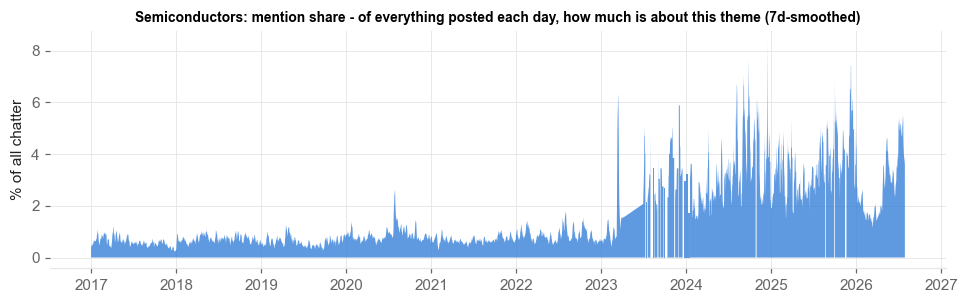

In [5]:
fig, ax = plt.subplots(figsize=(10.5, 2.8))
ax.fill_between(share.index, share.values, color=C1, alpha=0.75, lw=0)
ax.set_ylabel("% of all chatter")
ax.set_title(f"{theme_label(THEME)}: mention share - of everything posted "
             "each day, how much is about this theme (7d-smoothed)",
             fontsize=9)
despine(ax)
plt.show()

**Look at this:** the 2021 chip mania and the 2023–24 AI run both show as
broad swells; a share (not a raw count) is used so a platform-wide busy
day cannot fake a swell.

### The GET OUT ingredients (the "euphoria ending" bank: E1, E2, E3, E5
and the fade flag)

One simple chart per idea, titled in the words the dashboard uses
(`analytics/plain_english.py` — the same glossary everywhere).

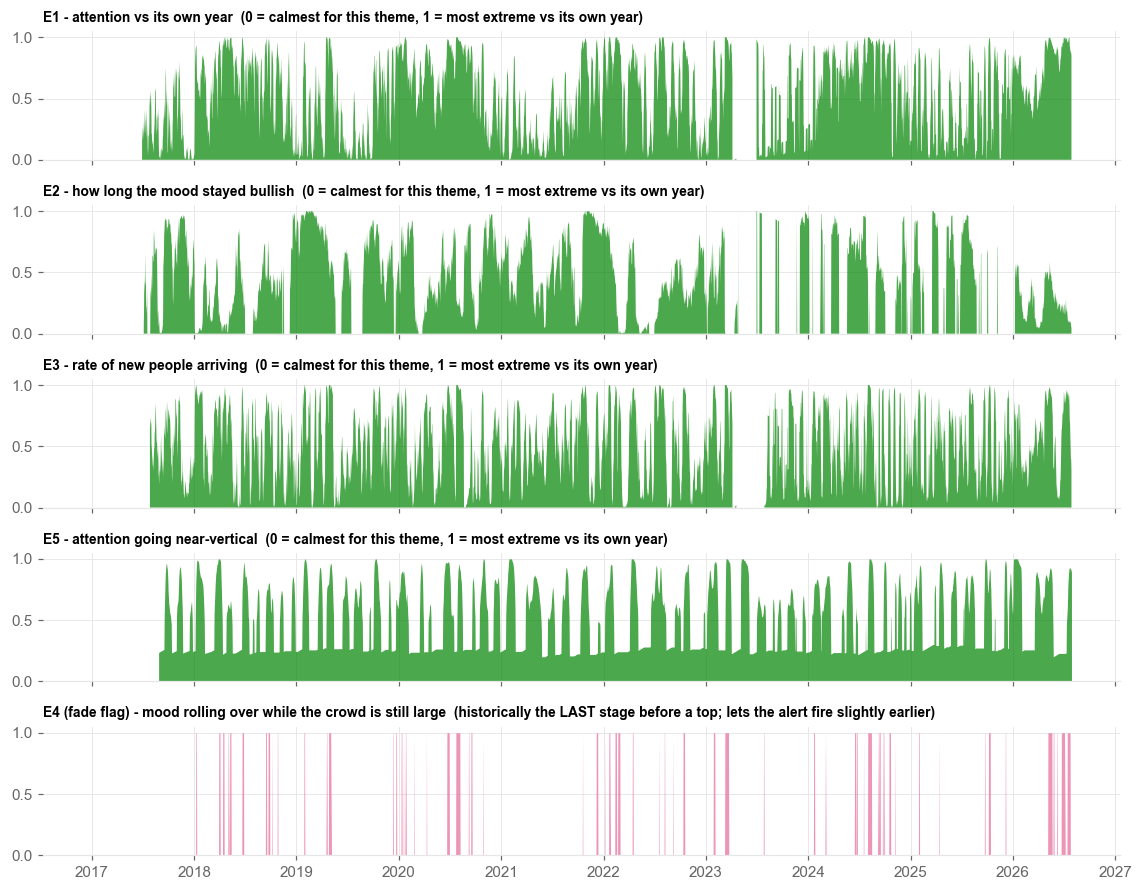

In [6]:
out_bank = [("e1", es.e1), ("e2", es.e2), ("e3", es.e3), ("e5", es.e5)]
fig, axes = plt.subplots(5, 1, figsize=(10.5, 8.2), sharex=True)
for ax, (name, s_) in zip(axes, out_bank):
    ax.fill_between(s_.index, s_.values, color=C2, alpha=0.7, lw=0)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{name.upper()} - {plain(name)}  (0 = calmest for this "
                 "theme, 1 = most extreme vs its own year)", fontsize=9,
                 loc="left")
    despine(ax)
ax = axes[4]
fade = es.fade.astype(float)
ax.fill_between(fade.index, fade.values, color=C3, alpha=0.8, lw=0)
ax.set_ylim(0, 1.05)
ax.set_title(f"E4 (fade flag) - {plain('fade')}  (historically the LAST "
             "stage before a top; lets the alert fire slightly earlier)",
             fontsize=9, loc="left")
despine(ax)
fig.tight_layout()
plt.show()

**Look at this:** no single panel is the signal. E1 (loudness) spikes
often; E2 (weeks of one-way mood) is rarer; the moments that matter are
where SEVERAL panels are high at once — which is exactly why the score
is their average (§5) and not any one of them.

### The GET IN ingredients (the "euphoria starting" bank)

Same construction, aimed at the LEFT side of an episode — the crowd
*arriving* rather than the crowd *peaking*.

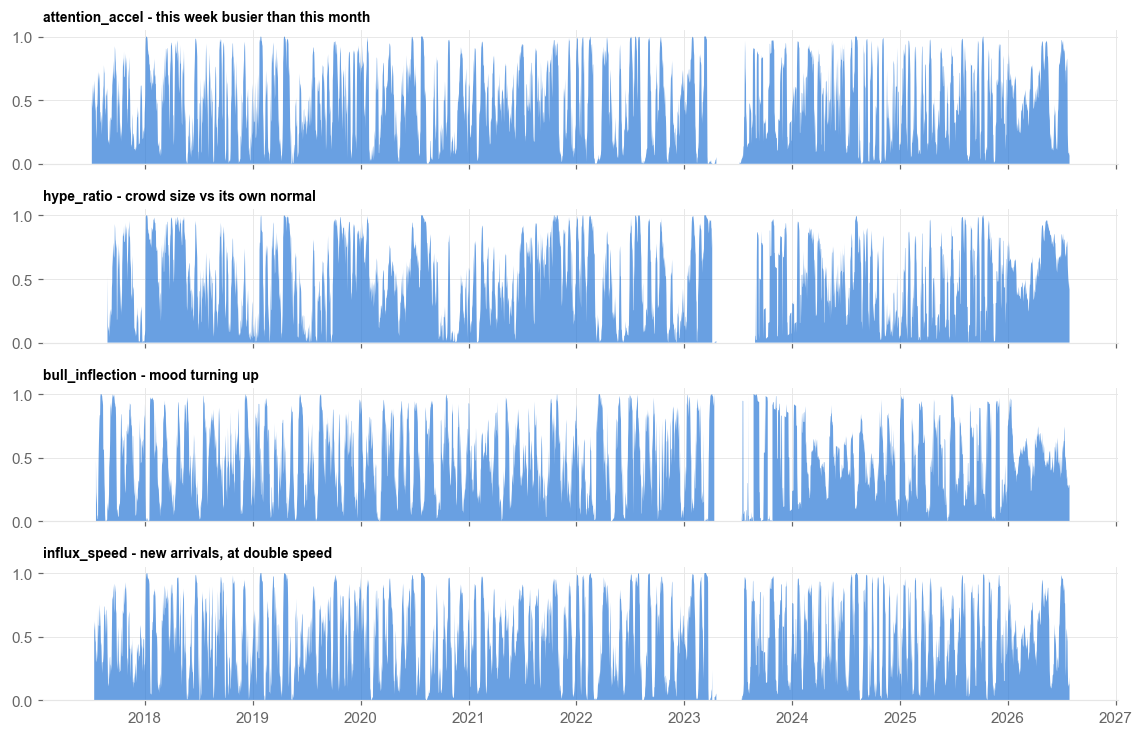

(the fifth GET IN ingredient, attention_convexity, is E5 above - the same measurement reused, disclosed as identical, never counted as two pieces of evidence)


In [7]:
in_bank = ["attention_accel", "hype_ratio", "bull_inflection",
           "influx_speed"]
fig, axes = plt.subplots(4, 1, figsize=(10.5, 6.8), sharex=True)
for ax, name in zip(axes, in_bank):
    s_ = onset_feats[name]
    ax.fill_between(s_.index, s_.values, color=C1, alpha=0.7, lw=0)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{name} - {plain(name)}", fontsize=9, loc="left")
    despine(ax)
fig.tight_layout()
plt.show()
print("(the fifth GET IN ingredient, attention_convexity, is E5 above - "
      "the same measurement reused, disclosed as identical, never counted "
      "as two pieces of evidence)")

---
## §3 THE FEATURE MENU: everything considered, and what earned a place

**Eleven candidate measurements were on the table**: the five incumbent
top-bank features (E1, E2, E3, E5, fade), five new onset candidates, and
`source_breadth` (how many platforms are talking). Notebook 02 graded
each against the price-defined episode labels — AUROC with an
instrument-cluster confidence interval; a feature counts as separating
only if the interval clears the 0.5 coin-flip line. Bars below are read
from that record (`nb02_feature_stats.json`).

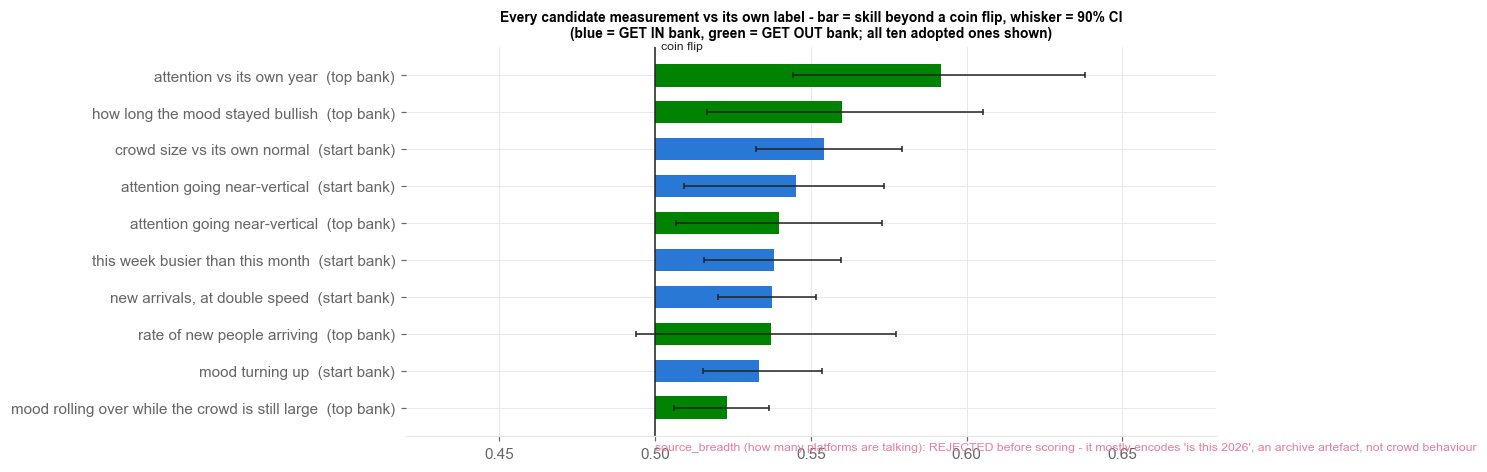

In [8]:
nb02 = pd.DataFrame(json.load(open(RESEARCH_DIR /
                                   "nb02_feature_stats.json")))
own = pd.concat([
    nb02[(nb02.label == "y_onset") & nb02.feature.isin(
        ["attention_accel", "hype_ratio", "bull_inflection",
         "influx_speed", "attention_convexity"])],
    nb02[(nb02.label == "y_top") & nb02.feature.isin(
        ["e1", "e2", "e3", "e5", "fade"])],
]).sort_values("auroc").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
colors = [C1 if lab == "y_onset" else C2 for lab in own.label]
labels = [f"{plain(f)}  ({'start' if lab == 'y_onset' else 'top'} bank)"
          for f, lab in zip(own.feature, own.label)]
ax.barh(labels, own.auroc - 0.5, left=0.5, color=colors, height=0.6)
ax.errorbar(own.auroc, np.arange(len(own)),
            xerr=[own.auroc - own.ci_lo, own.ci_hi - own.auroc],
            fmt="none", ecolor=INK, elinewidth=1, capsize=2)
ax.axvline(0.5, color=INK, lw=1)
ax.text(0.502, len(own) - 0.3, "coin flip", fontsize=8, color=INK)
# the rejected candidate, drawn without a bar - it was disqualified BEFORE
# scoring (its variation encodes which YEAR it is, not what the crowd did:
# the archive only gained its 2nd and 3rd source in 2026)
ax.text(0.5, -1.15, "source_breadth (how many platforms are talking): "
        "REJECTED before scoring - it mostly encodes 'is this 2026', "
        "an archive artefact, not crowd behaviour", fontsize=8, color=C3)
ax.set_xlim(0.42, 0.68)
ax.set_title("Every candidate measurement vs its own label - bar = skill "
             "beyond a coin flip, whisker = 90% CI\n(blue = GET IN bank, "
             "green = GET OUT bank; all ten adopted ones shown)",
             fontsize=9)
despine(ax)
plt.show()

**Look at this — two honest facts at once:**

1. **Every bar is short.** No single measurement detects euphoria
   (AUROC 0.51–0.59, against 0.65+ for anything you would trade alone).
   The banks work because five weak-but-real signals must agree.
2. **The best-scoring candidate is the one that was thrown out.**
   `source_breadth` topped the raw leaderboard and was rejected anyway,
   because its "skill" was the shape of the archive (new platforms added
   in 2026), not the crowd. A feature that works for the wrong reason is
   a research false positive — catching it is the point of the battery.

---
## §4 THE THRESHOLDS: sweep, mark, freeze

Every important constant was **swept** — run the whole walk-forward
evaluation at each candidate value, plot the trade-off, apply one
pre-stated rule: *inside the false-alarm budget (0.23 per
instrument-year, the level the desk had already accepted), take the
value that captures the most episodes.* Three examples below, read from
notebook 04's saved record (`nb04_evaluation.json` — recomputed there
from data on every research pass; notebook 04 §1 carries all ten).

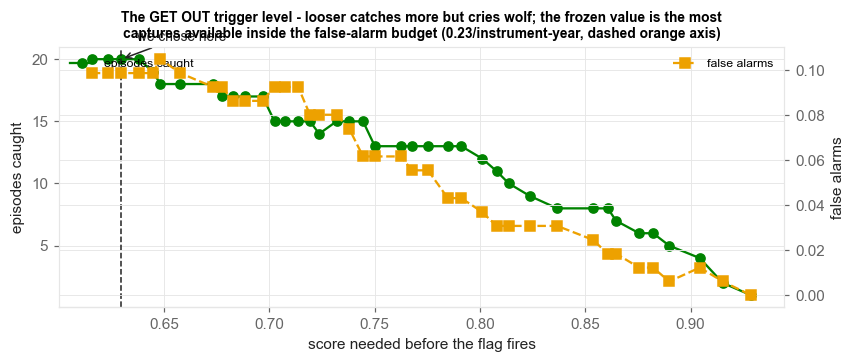

In [9]:
nb04 = json.load(open(RESEARCH_DIR / "nb04_evaluation.json"))
FA_BUDGET = nb04["headline"]["fa_budget"]
THR_OUT = nb04["frozen_thresholds"]["get_out"]

def sweep_panel(ax, df, xcol, ycol_cap, ycol_fa, chosen, xlabel, title):
    ax.plot(df[xcol], df[ycol_cap], "-o", color=C2, label="episodes caught")
    ax2 = ax.twinx()
    ax2.plot(df[xcol], df[ycol_fa], "--s", color=C4, label="false alarms")
    near = df.iloc[(df[xcol] - chosen).abs().idxmin()]
    ax.axvline(chosen, color=INK, ls="--", lw=1)
    ax.annotate("we chose here", (near[xcol], near[ycol_cap]),
                textcoords="offset points", xytext=(10, 12), fontsize=9,
                color=INK,
                arrowprops=dict(arrowstyle="->", color=INK, lw=1))
    ax.set_xlabel(xlabel)
    ax.set_ylabel("episodes caught")
    ax2.set_ylabel("false alarms")
    ax.set_title(title, fontsize=9)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax2.legend(frameon=False, fontsize=8, loc="upper right")
    despine(ax)

# (a) the GET OUT trigger level itself
grid = pd.DataFrame(nb04["threshold_sweeps"]["get_out_final_year_grid"])
fig, ax = plt.subplots(figsize=(8, 3.4))
sweep_panel(ax, grid, "thr", "captured", "fa_per_iy", THR_OUT,
            "score needed before the flag fires",
            "The GET OUT trigger level - looser catches more but cries "
            "wolf; the frozen value is the most\ncaptures available inside "
            f"the false-alarm budget ({FA_BUDGET}/instrument-year, dashed "
            "orange axis)")
plt.tight_layout(); plt.show()

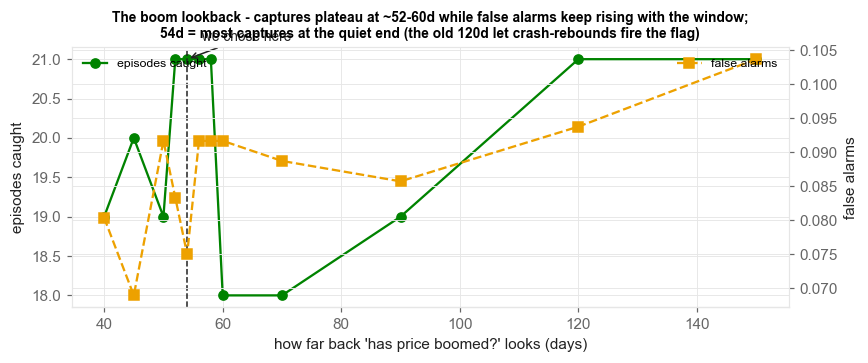

In [10]:
# (b) the boom-lookback window (the gate that stops crash-rebounds firing)
bw = pd.DataFrame(nb04["boom_window_sweep"])
fig, ax = plt.subplots(figsize=(8, 3.4))
sweep_panel(ax, bw, "window", "captured", "fa_per_iy", 54,
            "how far back 'has price boomed?' looks (days)",
            "The boom lookback - captures plateau at ~52-60d while false "
            "alarms keep rising with the window;\n54d = most captures at "
            "the quiet end (the old 120d let crash-rebounds fire the flag)")
plt.tight_layout(); plt.show()

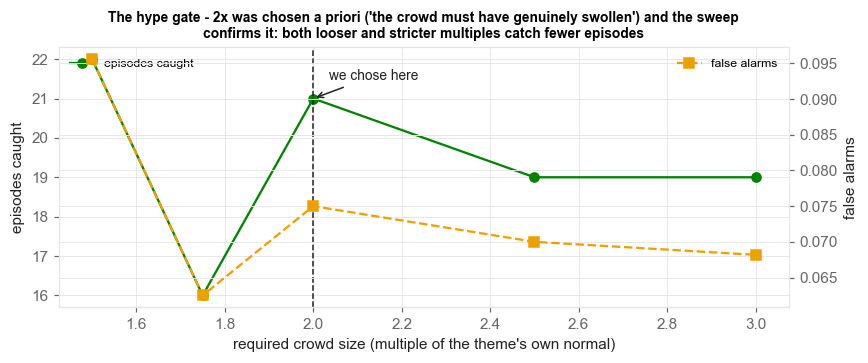

In [11]:
# (c) the hype gate: the crowd must be 2x its own normal before judging
hm = pd.DataFrame(nb04["hype_mult_sweep"])
fig, ax = plt.subplots(figsize=(8, 3.4))
sweep_panel(ax, hm, "hype_mult", "captured", "fa_per_iy", 2.0,
            "required crowd size (multiple of the theme's own normal)",
            "The hype gate - 2x was chosen a priori ('the crowd must have "
            "genuinely swollen') and the sweep\nconfirms it: both looser "
            "and stricter multiples catch fewer episodes")
plt.tight_layout(); plt.show()

**Look at these — one rule, three times:** each chart is a trade-off
between catching episodes (green) and crying wolf (orange). The dashed
line is where the project stands. Nothing was eyeballed: the same
pre-stated rule (max captures inside the accepted false-alarm budget)
picked every value, the sweep was walk-forward (thresholds chosen only
on years *before* the year being graded), and the chosen values are
**frozen** — they do not move when new data arrives, only when a
deliberate research pass re-runs the selection. Notebook 04 §1 has the
other seven constants, each with its own plot.

---
## §5 FACTORS → SIGNAL: two different machines, one price

The desk asked exactly the right question here: *"what differentiates a
GET OUT vs a GET IN trigger?"* Answer: **they are two different
machines** — different ingredients, different gates, different frozen
triggers — that are built the same *way* (average five ingredients,
gate, smooth over 7 days, fire on a frozen threshold, at most once per
21 days). Panel A below is the GET OUT machine, panel B the GET IN
machine, panel C the price both act on.

### What makes a GET OUT different from a GET IN

| | **GET OUT** (euphoria ending) | **GET IN** (euphoria starting) |
|---|---|---|
| the question it asks | is the crowd AT its peak? | is the crowd just ARRIVING? |
| its five ingredients | attention vs its own year · how long the mood stayed bullish · rate of new people arriving · attention going near-vertical · mood rolling over while the crowd is still large | this week busier than this month · crowd size vs its own normal · mood turning up · new arrivals, at double speed · attention going near-vertical |
| its gates | crowd ≥ **2×** its own normal **AND** price already ≥25% above its recent low — a boom must exist before it can end | crowd ≥ **1.10×** its own normal **AND** not already end-stage — you cannot call a *start* on a day that satisfies every *ending* gate |
| its frozen trigger | score ≥ **0.62** (dashed dark red, panel A) | score ≥ **0.86** (dashed green, panel B) |
| what it means for the desk | risk warning — when it is right, the sharp fall typically starts within days | timing — the run-up typically has ~2 months still ahead |

(Ingredient wording from `analytics/plain_english.py`, identical to the
dashboard's; the triggers are the walk-forward-frozen values from §4 /
notebook 04 §1.1. One ingredient — *attention going near-vertical* — is
shared by both banks, disclosed in §2 as the same measurement, never
counted as two pieces of evidence.)

Everything below is read from the production store
(`euphoria_desk.parquet`) — the same file the dashboard reads, so this
chart cannot disagree with the screen.

C:\Users\alexd\AppData\Local\Temp\ipykernel_49076\3958815648.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(out_stack.index).fillna(False)
C:\Users\alexd\AppData\Local\Temp\ipykernel_49076\3958815648.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .reindex(in_stack.index).fillna(False)
C:\Users\alexd\AppData\Local\Temp\ipykernel_49076\3958815648.py:75: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to 

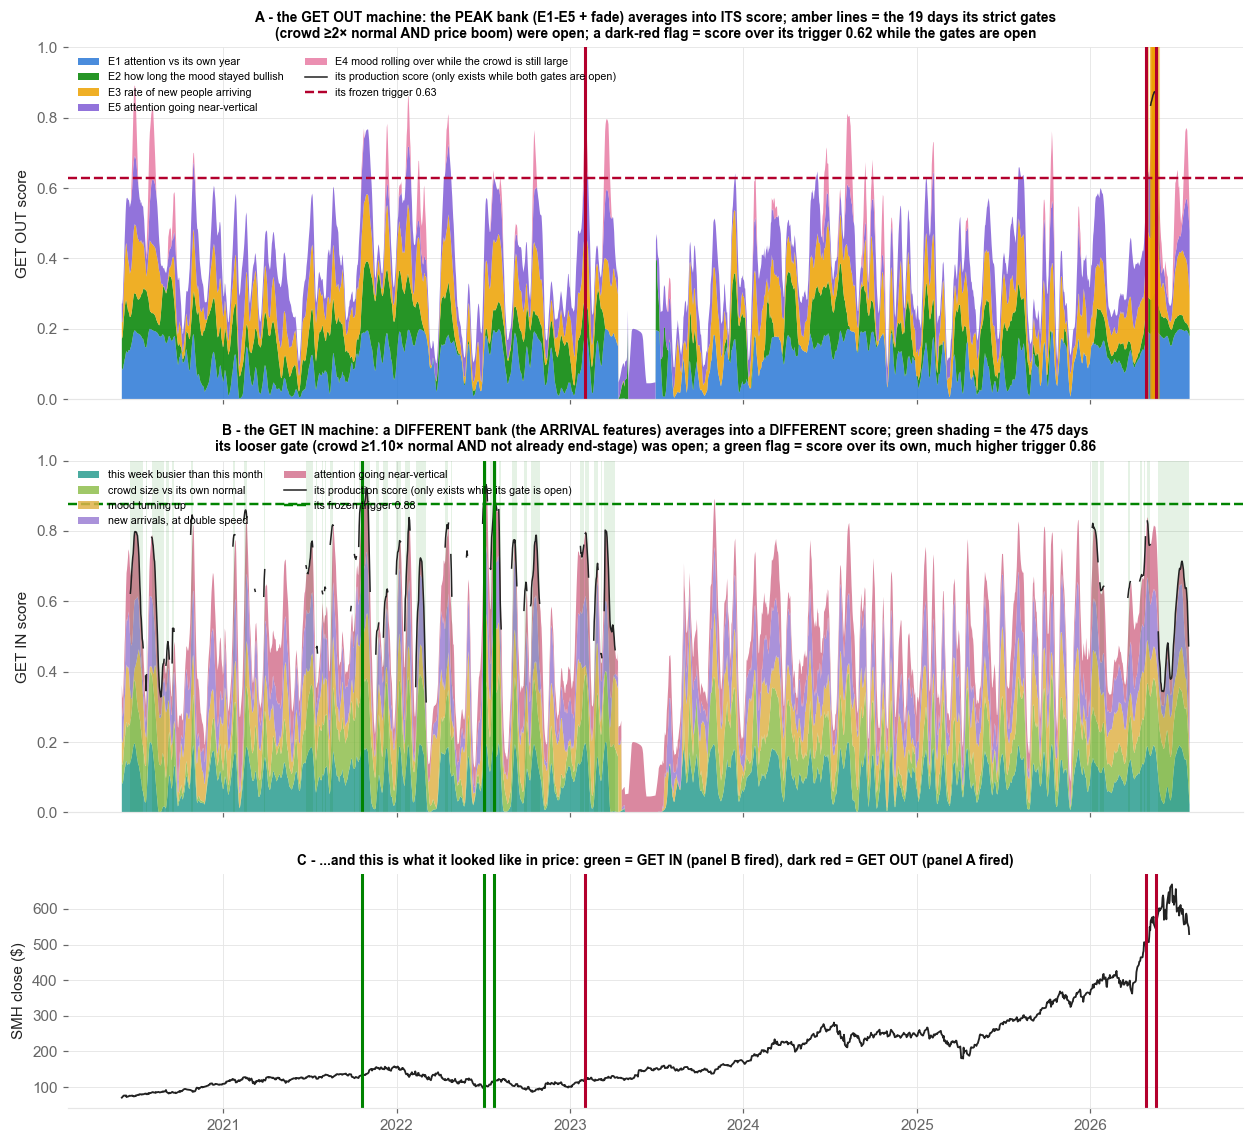

Semiconductors: 4 GET IN and 3 GET OUT flags in the production store (one 2017 GET IN sits before this chart's window). Silence is the default for both machines - but for opposite reasons: GET OUT's gates were open on 19 days here, GET IN's on 475, and GET IN pays for its looser gate with a far higher trigger. How well flags like these performed, judged walk-forward against price-defined episodes, is notebook 04 §3-§4 (this theme's own scorecard is §4 with SAMPLE_NAME='semiconductors').


In [12]:
desk = pd.read_parquet(ROOT / "data" / "processed" /
                       "euphoria_desk.parquet")
desk["date"] = pd.to_datetime(desk["date"])
ds = desk[desk["name"] == THEME].set_index("date").sort_index()
THR_IN = nb04["frozen_thresholds"]["get_in"]
LO = "2020-06-01"                       # the display window

# GET OUT committee: each ingredient contributes score/5, 7d-smoothed
out_parts = {f"{n.upper()} {plain(n)}": getattr(es, n) for n in
             ("e1", "e2", "e3", "e5")}
out_parts["E4 " + plain("fade")] = es.fade.astype(float)
out_stack = (pd.DataFrame(out_parts)
             .rolling(7, min_periods=1).mean() / 5.0).loc[LO:]
gates_out = ((ds["hype_raw"] >= 2.0) & ds["boom_state"].astype(bool)) \
    .reindex(out_stack.index).fillna(False)

# GET IN committee: its own five ingredients, same construction
in_parts = {plain(n): onset_feats[n] for n in
            ("attention_accel", "hype_ratio", "bull_inflection",
             "influx_speed", "attention_convexity")}
in_stack = (pd.DataFrame(in_parts)
            .rolling(7, min_periods=1).mean() / 5.0).loc[LO:]
gates_in = ((ds["hype_raw"] >= 1.10) & ~ds["end_stage"].astype(bool)) \
    .reindex(in_stack.index).fillna(False)

fig, axes = plt.subplots(3, 1, figsize=(11.5, 10.5),
                         gridspec_kw={"height_ratios": [3, 3, 2]},
                         sharex=True)

# ---- Panel A: the GET OUT machine ----------------------------------------
ax = axes[0]
ax.stackplot(out_stack.index,
             [out_stack[c].fillna(0).values for c in out_stack],
             labels=list(out_stack.columns),
             colors=[C1, C2, C4, "#7f5bd5", C3], alpha=0.85, lw=0)
sc = ds["out_score"].reindex(out_stack.index)
ax.plot(sc.index, sc.values, color=INK, lw=1.0,
        label="its production score (only exists while both gates are "
        "open)")
ax.axhline(THR_OUT, color="#b3002d", lw=1.6, ls="--",
           label=f"its frozen trigger {THR_OUT:.2f}")
# GET OUT's gates open on only a handful of DAYS in nine years - a
# translucent span would be subpixel, so each open day gets an amber line
n_open_out = int(gates_out.sum())
for d in out_stack.index[gates_out]:
    ax.axvline(d, color=C4, alpha=0.4, lw=2, zorder=1)
for d in ds.index[ds["get_out"]]:
    if d >= out_stack.index[0]:
        ax.axvline(d, color="#b3002d", lw=2)
ax.set_ylim(0, 1.0)
ax.set_ylabel("GET OUT score")
ax.set_title(f"A - the GET OUT machine: the PEAK bank (E1-E5 + fade) "
             f"averages into ITS score; amber lines = the {n_open_out} "
             "days its strict gates\n(crowd ≥2× normal AND price boom) "
             "were open; a dark-red flag = score over its trigger 0.62 "
             "while the gates are open", fontsize=9)
ax.legend(frameon=False, fontsize=7, ncol=2, loc="upper left")
despine(ax)

# ---- Panel B: the GET IN machine ------------------------------------------
ax = axes[1]
ax.stackplot(in_stack.index,
             [in_stack[c].fillna(0).values for c in in_stack],
             labels=list(in_stack.columns),
             colors=["#2a9d8f", "#8fbf4d", "#e0b34a", "#9b7fd4",
                     "#d4738f"], alpha=0.85, lw=0)
sci = ds["in_score"].reindex(in_stack.index)
ax.plot(sci.index, sci.values, color=INK, lw=1.0,
        label="its production score (only exists while its gate is open)")
ax.axhline(THR_IN, color=C2, lw=1.6, ls="--",
           label=f"its frozen trigger {THR_IN:.2f}")
# GET IN's gate is looser and opens for whole STRETCHES - shade them
n_open_in = int(gates_in.sum())
for lo_, hi_ in zip(in_stack.index[gates_in & ~gates_in.shift(1)
                                   .fillna(False)],
                    in_stack.index[gates_in & ~gates_in.shift(-1)
                                   .fillna(False)]):
    ax.axvspan(lo_, hi_, color=C2, alpha=0.10, lw=0)
for d in ds.index[ds["get_in"]]:
    if d >= in_stack.index[0]:
        ax.axvline(d, color=C2, lw=2)
ax.set_ylim(0, 1.0)
ax.set_ylabel("GET IN score")
ax.set_title(f"B - the GET IN machine: a DIFFERENT bank (the ARRIVAL "
             "features) averages into a DIFFERENT score; green shading = "
             f"the {n_open_in} days\nits looser gate (crowd ≥1.10× normal "
             "AND not already end-stage) was open; a green flag = score "
             "over its own, much higher trigger 0.86", fontsize=9)
ax.legend(frameon=False, fontsize=7, ncol=2, loc="upper left")
despine(ax)

# ---- Panel C: the price both machines act on ------------------------------
ax = axes[2]
px = (pd.read_parquet(ROOT / "data" / "prices" / "prices.parquet")
      .query("symbol == 'SMH'"))
px = px.assign(date=pd.to_datetime(px["date"])).set_index("date")[
    "px_last"].sort_index().loc[out_stack.index[0]:]
ax.plot(px.index, px.values, color=INK, lw=1.2)
for d in ds.index[ds["get_out"]]:
    if d >= out_stack.index[0]:
        ax.axvline(d, color="#b3002d", lw=2)
for d in ds.index[ds["get_in"]]:
    if d >= out_stack.index[0]:
        ax.axvline(d, color=C2, lw=2)
ax.set_ylabel("SMH close ($)")
ax.set_title("C - ...and this is what it looked like in price: green = "
             "GET IN (panel B fired), dark red = GET OUT (panel A fired)",
             fontsize=9)
loc = mdates.AutoDateLocator(minticks=4, maxticks=9)
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
despine(ax)
fig.tight_layout()
plt.show()

n_in, n_out = int(ds["get_in"].sum()), int(ds["get_out"].sum())
print(f"{theme_label(THEME)}: {n_in} GET IN and {n_out} GET OUT flags in "
      "the production store (one 2017 GET IN sits before this chart's "
      "window). Silence is the default for both machines - but for "
      f"opposite reasons: GET OUT's gates were open on {n_open_out} days "
      f"here, GET IN's on {n_open_in}, and GET IN pays for its looser "
      "gate with a far higher trigger. How well flags like these "
      "performed, judged walk-forward against price-defined episodes, is "
      "notebook 04 §3-§4 (this theme's own scorecard is §4 with "
      f"SAMPLE_NAME='{THEME}').")

---
## §6 WHAT IT TAKES TO FIRE: one real flag, dissected day by day

**WHY THIS**
- §5 showed the machinery across nine years; this section slows one real
  firing down to the day-by-day arithmetic, so "why did it fire?" has a
  worked answer a reader can recompute by hand.
- the flag: **semiconductors GET OUT, 28 Apr 2026** — the newest full
  episode in the production store.

**THE FIRING CHECKLIST** (every line must hold at once; each is a frozen
constant justified in notebook 04 §1):

| # | condition | constant |
|---|---|---|
| 1 | the crowd is at least **2×** its own 120d normal (the hype gate) | `EUPHORIA_HYPE_MULT` |
| 2 | the price is in a confirmed **boom** off its rolling low | `EUPHORIA_BOOM_MIN_*` |
| 3 | attention sits in the top decile of its own year (**e1 ≥ 0.90**) | `EUPHORIA_ATT_GATE` |
| 4 | bullish persistence is positive (**e2 > 0**) | design gate |
| 5 | the **7-calendar-day mean** of the gated committee average crosses the frozen trigger | walk-forward frozen |
| 6 | no GET OUT in the last **21 days** (cooldown) | `EUPHORIA_COOLDOWN_DAYS` |

The committee average is FIVE EQUAL WEIGHTS — each factor contributes
value/5, so no single ingredient can fire it alone: even a factor pinned
at its all-time extreme (1.00) contributes only 20% of the score, ~32% of
the trigger. A flag needs a broad committee AND open gates AND a full
week of it.

In [13]:
desk_s = pd.read_parquet(ROOT / "data" / "processed" /
                         "euphoria_desk.parquet")
desk_s["date"] = pd.to_datetime(desk_s["date"])
_rep = json.load(open(ROOT / "data" / "processed" /
                      "euphoria_desk_report.json"))
THR_OUT_LIVE = _rep["get_out"]["live_threshold"]
lv = pd.read_parquet(ROOT / "data" / "processed" /
                     "euphoria_levels.parquet")
lv["date"] = pd.to_datetime(lv["date"])

FLAG_DAY = pd.Timestamp("2026-04-28")
_ds = (desk_s[desk_s["name"] == THEME].set_index("date").sort_index())
_le = (lv[lv["name"] == THEME].set_index("date").sort_index())
assert bool(_ds.loc[FLAG_DAY, "get_out"]), "the example flag moved - rerun"

win = pd.date_range(FLAG_DAY - pd.Timedelta(days=9), FLAG_DAY, freq="D")
rows = []
for d in win:
    if d not in _le.index:
        continue
    r = _le.loc[d]
    raw = float((r["e1"] + r["e2"] + r["e3"] + r["e5"]
                 + float(bool(r["fade"]))) / 5)
    gates_score = (r["e1"] >= 0.90) and (r["e2"] > 0)
    dr = _ds.loc[d] if d in _ds.index else None
    rows.append({
        "date": d.date(),
        "e1 attention": round(float(r["e1"]), 2),
        "e2 mood held": round(float(r["e2"]), 2),
        "e3 arrivals": round(float(r["e3"]), 2),
        "e5 vertical": round(float(r["e5"]), 2),
        "fade": bool(r["fade"]),
        "raw avg": round(raw, 3),
        "counted (e1&e2 gates)": round(raw, 3) if gates_score else 0.0,
        "crowd x": (round(float(dr["hype_raw"]), 2)
                    if dr is not None and pd.notna(dr.get("hype_raw"))
                    else None),
        "candidacy (2x+boom)": bool(
            dr is not None and pd.notna(dr.get("hype_raw"))
            and dr["hype_raw"] >= 2.0 and bool(dr.get("boom_state"))),
        "7d smoothed score": (round(float(dr["out_score"]), 3)
                              if dr is not None
                              and pd.notna(dr.get("out_score")) else None),
        "FIRED": bool(dr is not None and dr.get("get_out")),
    })
tab = pd.DataFrame(rows)
print(f"frozen GET OUT trigger: {THR_OUT_LIVE:.3f} "
      "(firing = '7d smoothed score' >= trigger while candidacy holds)\n")
print(tab.to_string(index=False))

frozen GET OUT trigger: 0.630 (firing = '7d smoothed score' >= trigger while candidacy holds)

      date  e1 attention  e2 mood held  e3 arrivals  e5 vertical  fade  raw avg  counted (e1&e2 gates)  crowd x  candidacy (2x+boom)  7d smoothed score  FIRED
2026-04-19          0.74          0.21         0.53         0.69 False    0.433                  0.000     1.19                False                NaN  False
2026-04-20          0.69          0.21         0.51         0.70 False    0.421                  0.000     1.14                False                NaN  False
2026-04-21          0.67          0.25         0.48         0.69 False    0.418                  0.000     1.09                False                NaN  False
2026-04-22          0.62          0.26         0.36         0.68 False    0.384                  0.000     1.04                False                NaN  False
2026-04-23          0.70          0.34         0.53         0.70 False    0.455                  0.000     1.1

**Read the table like the detector does.** In the lead-in days the
committee was already warm (raw averages in the 0.5s–0.6s) but the flag
could not exist: the crowd sat *below* the 2× hype bar, so there was no
candidacy — the score column is empty because the exit question was not
being asked. On the final days everything lines up at once: the crowd
clears 2× its own normal, the price is in a confirmed boom, attention is
in the top decile of its own year (e1 ≥ 0.90) with persistence positive,
and the 7-calendar-day mean of the counted committee readings reaches the
frozen trigger — **that crossing, with every gate open, is the flag**.
Since the 2026-07-31 smoothing fix, that week is always the last seven
*calendar* days: evidence older than a week can never reach a trigger.

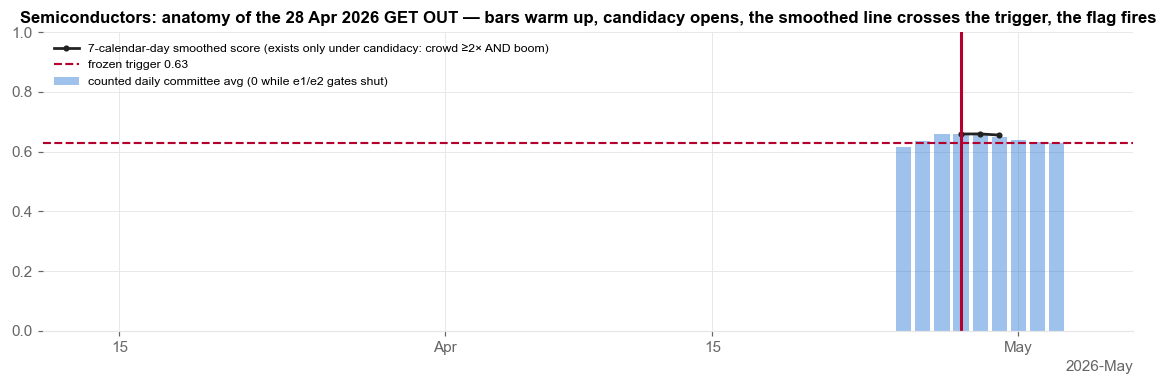

Look at: the bars alone never fire anything - the flag needs the black line (a full week of counted readings) over the dashed trigger while the gates hold. One loud afternoon cannot do it; neither can last year's mania.


In [14]:
# the same story as a picture: counted daily readings (bars), the
# 7d-smoothed score that actually fires (line), the frozen trigger
# (dashed), and the flag (red rule)
show = pd.date_range(FLAG_DAY - pd.Timedelta(days=45), FLAG_DAY
                     + pd.Timedelta(days=6), freq="D")
bar_v, bar_d = [], []
for d in show:
    if d in _le.index:
        r = _le.loc[d]
        raw = float((r["e1"] + r["e2"] + r["e3"] + r["e5"]
                     + float(bool(r["fade"]))) / 5)
        bar_d.append(d)
        bar_v.append(raw if (r["e1"] >= 0.90 and r["e2"] > 0) else 0.0)
sc = _ds["out_score"].reindex(show)
fig, ax = plt.subplots(figsize=(10.5, 3.6))
ax.bar(bar_d, bar_v, width=0.8, color=C1, alpha=0.45,
       label="counted daily committee avg (0 while e1/e2 gates shut)")
ax.plot(sc.index, sc.values, color=INK, lw=1.8, marker="o", ms=3,
        label="7-calendar-day smoothed score (exists only under "
              "candidacy: crowd ≥2× AND boom)")
ax.axhline(THR_OUT_LIVE, color="#b3002d", ls="--", lw=1.4,
           label=f"frozen trigger {THR_OUT_LIVE:.2f}")
ax.axvline(FLAG_DAY, color="#b3002d", lw=2)
ax.set_ylim(0, 1.0)
ax.set_title(f"{theme_label(THEME)}: anatomy of the 28 Apr 2026 GET OUT — "
             "bars warm up, candidacy opens, the smoothed line crosses "
             "the trigger, the flag fires")
ax.legend(frameon=False, fontsize=8, loc="upper left")
despine(ax)
loc6 = mdates.AutoDateLocator(minticks=4, maxticks=8)
ax.xaxis.set_major_locator(loc6)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc6))
fig.tight_layout()
plt.show()
print("Look at: the bars alone never fire anything - the flag needs the "
      "black line (a full week of counted readings) over the dashed "
      "trigger while the gates hold. One loud afternoon cannot do it; "
      "neither can last year's mania.")

**Look at this, because it is the whole design in one picture:**

* the coloured stack is the committee — no single ingredient decides;
* the score (black) only *exists* on the amber days, because the gates
  (crowd swollen AND boom underway) are prerequisites, not suggestions —
  both gates were open on only a couple of dozen days in nine years,
  which is why the flag count is single digits, not dozens;
* the flag fires at a **frozen, walk-forward-chosen** trigger — nobody
  picked it by looking at this chart, and it does not move when new data
  arrives;
* and the bottom panel is the claim the desk can check by eye: the dark
  red lines sit at the crest of genuine booms, the green ones early in
  run-ups.

## Where to go next

* **"Prove those thresholds are best"** → notebook 04 §1 (a sweep plot
  for every constant).
* **"Prove the features are best"** → notebook 04 §2 (separation,
  tournament vs ML challengers, leave-one-out).
* **"How well does it actually perform?"** → notebook 04 §3 (hit rates
  at +5/+20/+84 trading days, median time to the fall, event studies),
  and §4 for any single name.
* **"What counts as an episode in the first place?"** → notebook 01.

*Runtime note: this walkthrough recomputes only the one-theme features;
every evaluation number is read from the saved research record, which is
why it runs in about a minute.*

In [15]:
print(f"total runtime {time.time()-NB_T0:.0f}s")

total runtime 6s
